In [54]:
import numpy as np
import matplotlib.pyplot as plt

In [55]:
def unit_impulse(t):
    return np.where(t == 0, 1, 0)

In [56]:
# -----------------------------
# Manual Convolution
# -----------------------------
def manual_convolution(x, h):
    N = len(x)
    M = len(h)
    y = np.zeros(N + M - 1)
    
    for n in range(len(y)):
        for k in range(M):
            if 0 <= n - k < N:
                y[n] += x[n - k] * h[k]
    
    return y


# -----------------------------
# Cross-Correlation
# -----------------------------
def cross_correlation(x, h):
    N = len(x)
    M = len(h)
    y = np.zeros(N + M - 1)
    
    h_rev = h[::-1]  # Reverse h for correlation
    
    for n in range(len(y)):
        for k in range(M):
            if 0 <= n - k < N:
                y[n] += x[n - k] * h_rev[k]
    
    return y

In [57]:
n = np.arange(0, 2)
x = unit_impulse(n) + 2 * unit_impulse(n - 1)
h = unit_impulse(n) - 0.5 * unit_impulse(n - 1)

In [58]:
x


array([1, 2])

In [59]:
h

array([ 1. , -0.5])

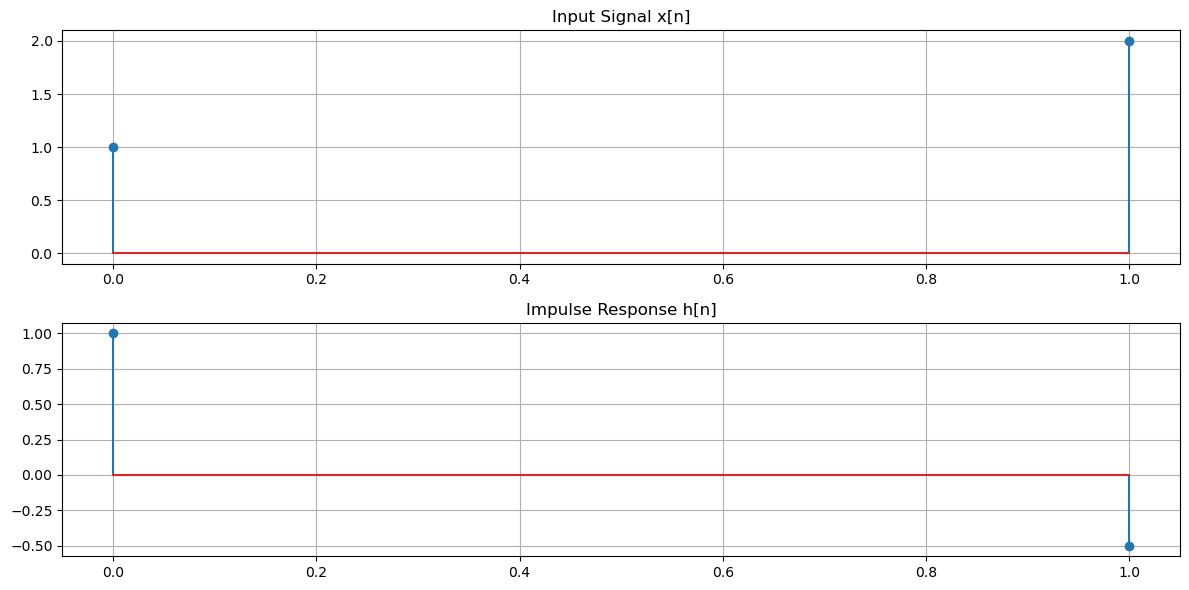

In [60]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.stem(n, x)
plt.title('Input Signal x[n]')
plt.grid()


plt.subplot(2, 1, 2)
plt.stem(n, h)
plt.title('Impulse Response h[n]')
plt.grid()

plt.tight_layout()
plt.show()

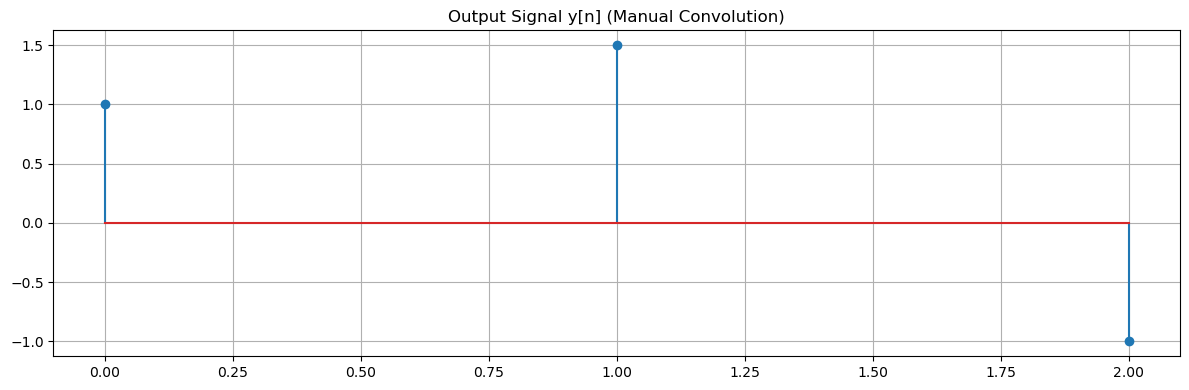

In [61]:
y_manual = manual_convolution(x, h)

plt.figure(figsize=(12, 4))
plt.stem(np.arange(len(y_manual)), y_manual)
plt.title('Output Signal y[n] (Manual Convolution)')
plt.grid()
plt.tight_layout()
plt.show()

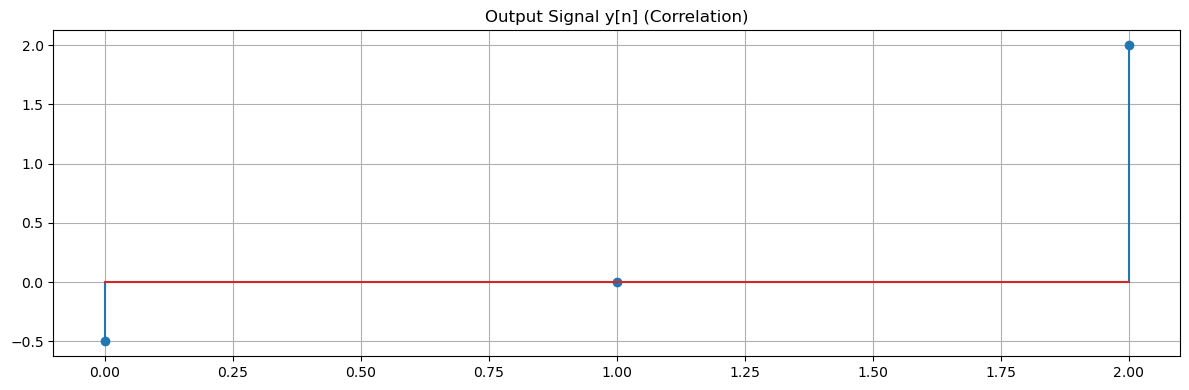

In [62]:
y_correlation = manual_convolution(x, h[::-1])
plt.figure(figsize=(12, 4))
plt.stem(np.arange(len(y_correlation)), y_correlation)
plt.title('Output Signal y[n] (Correlation)')
plt.grid()
plt.tight_layout()
plt.show()

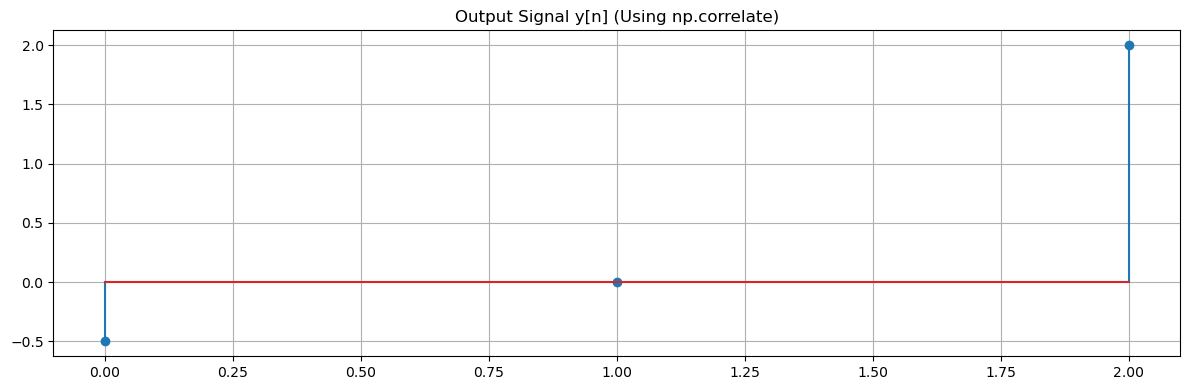

In [63]:
y = np.correlate(x, h, mode='full')
plt.figure(figsize=(12, 4))
plt.stem(np.arange(len(y)), y)
plt.title('Output Signal y[n] (Using np.correlate)')
plt.grid()
plt.tight_layout()
plt.show()


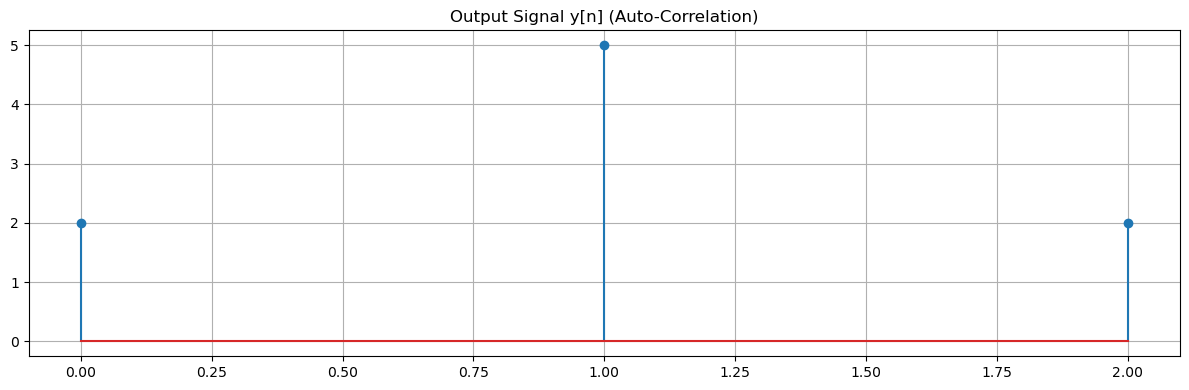

In [64]:
y = np.correlate(x, x, mode='full')
plt.figure(figsize=(12, 4))
plt.stem(np.arange(len(y)), y)
plt.title('Output Signal y[n] (Auto-Correlation)')
plt.grid()
plt.tight_layout()
plt.show()


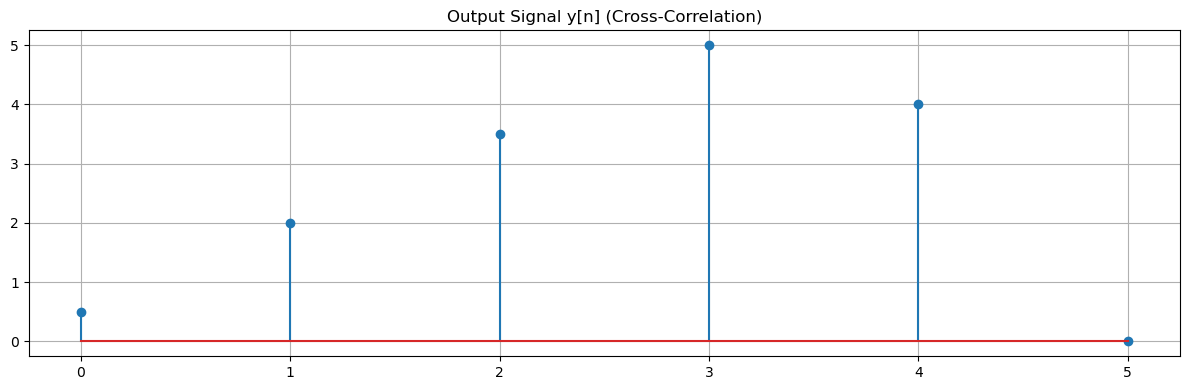

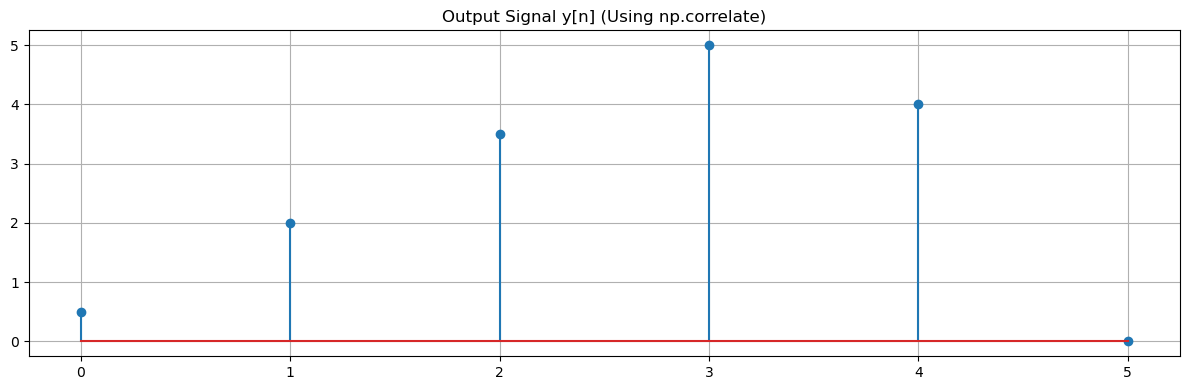

In [65]:
x = np.array([1, 2, 3, 4])
h = np.array([0, 1, 0.5])

y = cross_correlation(x, h)
plt.figure(figsize=(12, 4))
plt.stem(np.arange(len(y)), y)
plt.title('Output Signal y[n] (Cross-Correlation)')
plt.grid()
plt.tight_layout()
plt.show()


y = np.correlate(x, h, mode='full')
plt.figure(figsize=(12, 4))
plt.stem(np.arange(len(y)), y)
plt.title('Output Signal y[n] (Using np.correlate)')
plt.grid()
plt.tight_layout()
plt.show()